In [1]:

from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o')
small_llm = ChatOpenAI(model='gpt-4o-mini')

In [3]:
from langgraph.prebuilt import ToolNode
from place_tools import search_ancient_places, fetch_modern_places_by_names, journey_description_search, journey_route_search, ancient_keyword_search
tool_list = [search_ancient_places, journey_description_search, journey_route_search, fetch_modern_places_by_names, ancient_keyword_search]
llm_with_tools = llm.bind_tools(tool_list)
tool_node = ToolNode(tool_list) 

In [4]:
from langgraph.graph import MessagesState

class AgentState(MessagesState):
    query: str
    answer: str
    place_id_map: dict[str, str]
    recommended_questions: list[str]

In [5]:
from langgraph.graph import StateGraph
graph_builder = StateGraph(AgentState)

In [ ]:
from pathlib import Path
from langchain_core.messages import SystemMessage


# PRD가 시스템 프롬프트의 canonical source.
# 노트북은 agents/places/에서 실행된다고 가정 → 프로젝트 루트는 ../..
_PRD_PATH = Path("../../docs/agent-prd.md").resolve()
PLACE_AGENT_SYSTEM = _PRD_PATH.read_text(encoding="utf-8")


def place_agent(state: AgentState):
    messages = state['messages']
    response = llm_with_tools.invoke(
        [SystemMessage(content=PLACE_AGENT_SYSTEM)] + messages
    )
    return {'messages': [response]}

In [7]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

bible_general_agent_prompt = PromptTemplate.from_template(
    """
    성경 질문에 답하는 도우미.
    **언어 규칙: 사용자 질문 언어(한국어/영어)와 동일 언어로 답할 것.**

    규칙:
    - 3~5문장 이내로 간결히.
    - 성경 본문·인물·사건·신학 주제에 한정.
    - 확신 없으면 "성경에서 명확히 다루지 않는다"고 답할 것.
    - 서두·맺음말·이모지 금지.

    질문: {query}
    """
)

mini_llm = ChatOpenAI(
    model="gpt-4o-mini",
    max_tokens=400,
    temperature=0.2,
)

bible_general_agent_chain = bible_general_agent_prompt | mini_llm | StrOutputParser()

def bible_general_agent(state: AgentState):
    query = state['query']
    answer = bible_general_agent_chain.invoke({"query": query})

    return {'answer': answer}

In [8]:
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI


class NonBibleResponse(BaseModel):
    answer: str = Field(
        description=(
            "질문이 성경 도메인과 무관하다는 정중한 안내 메시지. 1~2문장. "
            "사용자 질문 언어(한국어/영어)와 동일 언어로 작성."
        )
    )
    recommended_questions: list[str] = Field(
        default_factory=list,
        max_length=3,
        description=(
            "사용자가 대신 물어볼 만한 성경 지리·지명 관련 예시 질문 3개. "
            "원 질문의 맥락(주제·인물·상황)과 연결 가능하면 그 쪽으로 유도. "
            "사용자 질문 언어와 동일 언어로 작성."
        ),
    )


non_bible_reject_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
        사용자 질문이 성경 도메인과 무관합니다.
        **언어 규칙: 사용자 질문 언어(한국어/영어)와 동일 언어로 답할 것.**

        - answer: 1~2문장. "성경과 무관한 질문이라 답변이 어렵다"는 정중한 안내.
        - recommended_questions: 사용자가 대신 물어볼 만한 성경 지리·지명 예시 질문 3개.
          원 질문의 맥락과 연결 가능하면 그쪽으로 유도.

        이모지·부연 설명 금지.
        """
    ),
    ("user", "질문: {query}"),
])

nano_llm = ChatOpenAI(
    model="gpt-4.1-nano",
    max_tokens=300,
    temperature=0.3,
)

non_bible_reject_chain = non_bible_reject_prompt | nano_llm.with_structured_output(NonBibleResponse)


def non_bible_reject(state: AgentState):
    query = state['query']
    result = non_bible_reject_chain.invoke({'query': query})
    return {
        'answer': result.answer,
        'recommended_questions': result.recommended_questions,
    }

In [9]:
from pydantic import BaseModel, Field
from typing import Literal
from langchain_core.prompts import ChatPromptTemplate

class Route(BaseModel):
    target: Literal['place_agent','bible_general_agent','non_bible_reject'] = Field(description='The target for the query to answer')

router_system_prompt = """
당신은 사용자 질문을 아래 세 target 중 하나로 분류하는 라우터입니다.
target은 반드시 'place_agent', 'bible_general_agent', 'non_bible_reject' 중 하나여야 합니다.

- 'place_agent': 질문이 성경의 지리·장소에 관한 경우.
  성경 지명(고대/현대), 인물·집단의 이동 경로·여정, 지역의 위치·의미,
  성경 지역과 현대 위치의 관계 등을 묻는 질문이 여기에 해당한다.
  예:
    "베들레헴은 어떤 곳이야?"
    "바울의 2차 전도여행 경로를 알려줘"
    "요셉이 형들에게 팔린 곳은 어디야?"
    "쿰란은 성경 어디에 나와?"
    "에덴동산은 지금 어디에 있어?"

- 'bible_general_agent': 질문이 성경과 관련 있지만 장소가 주된 초점이 아닌 경우.
  성경 인물의 성품·행적, 교리·신학, 사건의 의미, 구절 해석,
  신앙적 개념, 성경적 지침 등이 여기에 해당한다.
  예:
    "성령이란 무엇인가요?"
    "다윗은 어떤 왕이었어?"
    "요한복음 3장 16절의 의미는?"
    "선한 사마리아인의 비유를 설명해줘"
    "구약과 신약의 차이는?" 

- 'non_bible_reject': 질문이 성경 도메인과 무관한 경우.
  일상 잡담, 시사, 기술, 요리, 날씨, 취미 등 성경과 관련 없는
  모든 질문이 여기에 해당한다.
  예:
    "오늘 서울 날씨는?"
    "파이썬으로 웹 스크래핑 어떻게 해?"
    "요즘 볼만한 영화 추천해줘"
    "저녁 뭐 먹지?"

판단 규칙:
- 질문에 성경 지명이 명시적으로 등장하거나 인물·집단의 '이동/여정'을 묻는다면 'place_agent'.
- 성경에 등장하는 개념·인물·구절·교리를 묻지만 장소 이동이 초점이 아니라면 'bible_general_agent'.
- 성경적 요소가 전혀 없다면 'non_bible_reject'.
- 애매하면 성경 도메인 쪽으로 우선 분류하고, 장소가 조금이라도 관련되면 'place_agent'를 선택한다.

target만 반환하고 다른 텍스트는 출력하지 마세요.
"""


router_prompt = ChatPromptTemplate.from_messages([
    ('system',router_system_prompt),
    ('user','{query}')
])

structured_router_llm =small_llm.with_structured_output(Route)

def router(state:AgentState):
    query= state['query']
    router_chain = router_prompt | structured_router_llm
    route = router_chain.invoke({'query': query})
    print(f'route == {route}')
    print(f'route.target == {route.target}')

    return route.target

In [10]:
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.messages import ToolMessage


class RelevanceCheck(BaseModel):
    is_relevant: bool = Field(
        description="답변이 질문에 실제로 부합하고 사실적으로 문제가 없으면 true, 그렇지 않으면 false"
    )
    reason: str = Field(
        default="",
        description="판단 근거를 한 문장 이내로 짧게 기술"
    )


relevance_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
        당신은 답변이 사용자 질문과 도구 검색 결과에 얼마나 잘 부합하는지
        평가하는 판정자입니다.

        판단 기준:
        - 답변이 질문의 요지를 정면으로 다루는가.
        - 도구 결과가 있으면 답변이 그 결과에 근거하는가.
        - 서로 다른 장소를 하나로 합치거나, 도구 결과에 없는 place_id/좌표/현대
          지명을 만들어내지 않았는가.
        - 명백한 사실 오류나 회피성 답변이 아닌가.

        **아래 조건 중 하나라도 해당하면 반드시 is_relevant = false:**
        1. 도구 결과가 전부 비어있고([] 또는 빈 문자열), 답변에
           "정보가 없다", "명확한 지명이 제공되지 않았", "구체적 자료가 없",
           "다른 자료를 참고", "명시되지 않았", "제공되지 않았"
           같은 정보 부족을 인정하는 표현이 있는 경우.
           → rewrite 노드가 LLM 사전 지식으로 더 나은 답변을 만들어야 함.
        2. 답변이 질문의 핵심(지명·인물·사건)을 다루지 못하고 회피.
        3. 답변이 비어있거나 지나치게 모호.

        **예외 - 다음은 is_relevant = true 허용:**
        - 질문 자체가 성경 밖 초월적/추상적 주제(예: "천국은 어디?")이고
          답변이 성경적 관점에서 적절히 짚어준 경우.
        - 도구 결과가 존재하고 답변이 그 결과와 일관되게 작성된 경우.

        reason에는 판단 근거 한 문장만 짧게.
        """
    ),
    (
        "user",
        """
        질문:
        {query}

        도구 검색 결과:
        {tool_results}

        최종 답변:
        {answer}
        """
    ),
])

judge_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
relevance_chain = relevance_prompt | judge_llm.with_structured_output(RelevanceCheck)


def evaluate_answer(state: AgentState) -> Literal["rewrite", "format"]:
    tool_results = [
        message.content
        for message in state["messages"]
        if isinstance(message, ToolMessage)
    ]

    check = relevance_chain.invoke({
        "query": state["query"],
        "answer": state["messages"][-1].content,
        "tool_results": tool_results,
    })

    print(f">> [evaluate_answer] is_relevant={check.is_relevant} | reason={check.reason}")
    return "rewrite" if not check.is_relevant else "format"

In [11]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI


rewrite_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
        성경 지리·지명 전문가. DB 검색 정보 부족으로 사전 지식만으로 답할 것.
        **언어 규칙: 사용자 질문 언어(한국어/영어)와 동일 언어로 답할 것.**

        지침:
        - 성경 본문·전통·널리 알려진 학설 수준으로 답.
        - 확실한 사실은 단정, 이견이 있으면 "학자들 사이 의견이 갈리지만 흔히…" 첨언.
        - 좌표·place_id·확신 없는 수치는 답하지 말 것.
        - 성경에 없는 사항은 "성경에서 명확히 다루지 않음"이라 답.
        - 3~5문장 이내. 사과·메타 발언·이모지 금지.
        """
    ),
    ("user", "질문: {query}"),
])

rewrite_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.2, max_tokens=500)
rewrite_chain = rewrite_prompt | rewrite_llm | StrOutputParser()


def rewrite(state: AgentState):
    query = state["query"]

    print(f">> [rewrite] 진입 (LLM 자체 지식 기반 재답변)")

    answer = rewrite_chain.invoke({"query": query})

    print(f">> [rewrite] 답변 {len(answer)}자")

    return {"answer": answer}

In [12]:
import json
from langchain_core.messages import ToolMessage


def _extract_place_refs(tool_message_content: str) -> dict[str, str]:
    """도구 결과 JSON에서 {이름: place_id} 매핑을 뽑는다."""
    refs: dict[str, str] = {}
    try:
        data = json.loads(tool_message_content)
    except (TypeError, ValueError):
        return refs
    if not isinstance(data, list):
        return refs
    for item in data:
        if not isinstance(item, dict):
            continue
        place_id = item.get("place_id")
        if not place_id:
            continue
        for key in ("name_ko", "name_en"):
            name = item.get(key)
            if name:
                refs[name] = place_id
    return refs


def format(state: AgentState):
    messages = state["messages"]
    # rewrite에서 answer가 이미 세팅됐으면 그것 보존, 아니면 마지막 메시지 사용
    answer_text = state.get("answer") or messages[-1].content

    tool_message_count = sum(1 for m in messages if isinstance(m, ToolMessage))
    print(f">> [format] 진입 (전체 메시지 {len(messages)}개, ToolMessage {tool_message_count}개)")

    # 모든 tool 메시지에서 place 참조를 뽑아 그대로 매핑
    place_id_map: dict[str, str] = {}
    for msg in messages:
        if isinstance(msg, ToolMessage):
            place_id_map.update(_extract_place_refs(msg.content))

    print(f">> [format] place_id_map {len(place_id_map)}개, 답변 {len(answer_text)}자")

    return {
        "answer": answer_text,
        "place_id_map": place_id_map,
    }

In [13]:
graph_builder.add_node('place_agent', place_agent)
graph_builder.add_node('tools', tool_node)
graph_builder.add_node('bible_general_agent', bible_general_agent)
graph_builder.add_node('non_bible_reject', non_bible_reject)
graph_builder.add_node('rewrite', rewrite)
graph_builder.add_node('format', format)

In [14]:
from langgraph.graph import START, END
from typing import Literal


def route_from_agent(state: AgentState) -> Literal['tools', 'rewrite', 'format']:
    """place_agent 이후 다음 노드 결정.

    - 아직 tool 호출이 남아있으면 tools로
    - 끝났으면 evaluate_answer 결과에 따라 rewrite / format으로
    """
    last_message = state['messages'][-1]

    tool_calls = getattr(last_message, 'tool_calls', None)
    if tool_calls:
        tool_names = [tc.get('name', '?') for tc in tool_calls]
        print(f">> [route_from_agent] → tools ({len(tool_calls)}개: {tool_names})")
        return 'tools'

    decision = evaluate_answer(state)
    print(f">> [route_from_agent] → {decision}")
    return decision


# START → router → 세 도메인 중 하나
graph_builder.add_conditional_edges(START, router, {
    'place_agent': 'place_agent',
    'bible_general_agent': 'bible_general_agent',
    'non_bible_reject': 'non_bible_reject',
})

# place_agent → tools (반복) 또는 평가 결과 (rewrite / format)
graph_builder.add_conditional_edges('place_agent', route_from_agent, {
    'tools': 'tools',
    'rewrite': 'rewrite',
    'format': 'format',
})

# tools 결과는 다시 place_agent로
graph_builder.add_edge('tools', 'place_agent')

# rewrite도 format을 거쳐서 place_id_map을 채우고 종료
graph_builder.add_edge('rewrite', 'format')

# 종료 분기
graph_builder.add_edge('bible_general_agent', END)
graph_builder.add_edge('non_bible_reject', END)
graph_builder.add_edge('format', END)

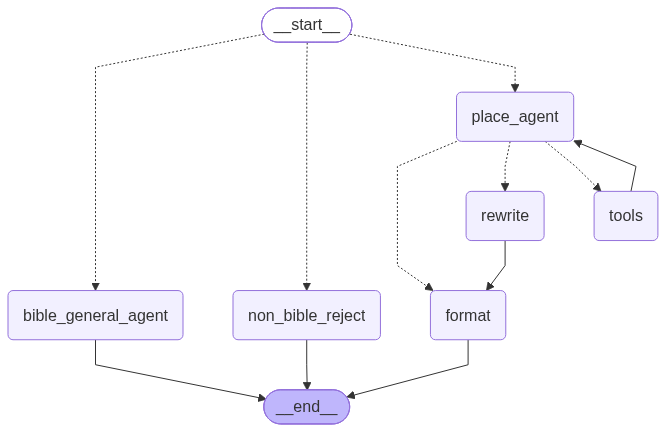

In [15]:
from IPython.display import Image, display
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))


In [18]:
query='이스마엘의 고향과 그들의 후손들의 거처를 알려주세요.'

In [19]:
from langchain_core.messages import HumanMessage

initial_state = {
    "query": query,
    "messages": [HumanMessage(content=query)],
}

print(f"[QUERY] {query}")
print("=" * 70)

for chunk in graph.stream(initial_state, stream_mode="updates"):
    for node_name, update in chunk.items():
        print(f"\n{'=' * 70}")
        print(f"NODE: {node_name}")
        print("-" * 70)

        if not update:
            print("(no state update)")
            continue

        for key, value in update.items():
            if key == "messages":
                for message in value:
                    message.pretty_print()
            elif key == "answer":
                print(f"\n[answer]\n{value}")
            elif key == "place_id_map":
                print(f"\n[place_id_map]  ({len(value)}개)")
                for name, pid in value.items():
                    print(f"  {name}  →  {pid}")
            elif key == "recommended_questions":
                print(f"\n[recommended_questions]  ({len(value)}개)")
                for i, q in enumerate(value, 1):
                    print(f"  {i}. {q}")
            else:
                print(f"[{key}] {value}")

[QUERY] 이스마엘의 고향과 그들의 후손들의 거처를 알려주세요.
route == target='place_agent'
route.target == place_agent
>> [route_from_agent] → tools (1개: ['ancient_keyword_search'])

NODE: place_agent
----------------------------------------------------------------------
================================== Ai Message ==================================
Tool Calls:
  ancient_keyword_search (call_4UeFJpCBWttx89HKb2DqtzNL)
 Call ID: call_4UeFJpCBWttx89HKb2DqtzNL
  Args:
    query: 이스마엘의 고향과 그 후손의 거처

NODE: tools
----------------------------------------------------------------------
================================= Tool Message =================================
Name: ancient_keyword_search

["Paran", "Havilah", "Shur"]
>> [route_from_agent] → tools (1개: ['search_ancient_places'])

NODE: place_agent
----------------------------------------------------------------------
================================== Ai Message ==================================
Tool Calls:
  search_ancient_places (call_QZ3uxXxCPV9sDRnlsGYOyPts